<p>
<h1><b><center></center></b></h1>
<center><img src="https://drive.google.com/uc?id=1UJc1ci41G6ahJ7ProKvunUOIBcTXZ6ZG" align="center" width="550"></center>
</p>
<h1><b><center>Mecánica Celeste</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Proyecto del Curso</center></b><h2>
<h3><b><center>La aproximación de Apophis en 2029</center></b><h3>
<h7><center><i>Vanessa Garcia</i></center><h7>
</p>

## Enunciado

<center>
<img src="https://starwalk.space/gallery/images/apophis-size/1920x1080.jpg" align="center" width="100%"></center>

En abril de 2029 el asteroide **(99942) Apophis** tendrá [una aproximación extrema con la Tierra](https://arxiv.org/pdf/2201.12205]). Por el tamaño del asteroide, esta aproximación es considerada uno de los eventos astronómicos más importantes de esta década. En este proyecto usaremos la teoría, los métodos y los algorítmos vistos en el curso de Mecánica Celeste para estudiar la aproximación del asteroide.

El objetivo de este trabajo es que experimentes de primera mano lo que las personas expertas en mecánica celeste hacen cuando estudian las amenazas de asteroides. Aprovecha cada cosa que veas en el curso para crear un reporte científico que explore a fondo las características dinámicas de esta aproximación.

## Algunas ideas

Existen muchas maneras de aplicar la teoría que veremos en el curso en este problema y no queremos sesgar tu elección de los temas o cálculos que quieras escoger para aplicarla. Sin embargo aquí van algunas ideas de cálculos que se podrían hacer:
- Integración de la trayectoria del asteroide usando un integrador de N cuerpos y teniendo en cuenta los efectos de todos los planetas.
- Cálculo de la fecha y hora exacta de aproximación a la Tierra.
- Determinación de la distancia mínima de la órbita del asteroide a la órbita de la Tierra.
- Cálculo usando solo la teoría del problema de los dos cuerpos de la aproximación y comparación con la teoría de N cuerpos.
- Cálculo del cambio de la órbita heliocéntrica del asteroide después de su paso cerca de la Tierra.
- Aplicación de la teoría del problema de N cuerpos al asteroide.

En todos los casos debe ser evidente cómo estás usando los resultados teóricos que vemos en el curso.

## Entregables

El entregable del proyecto es **un notebook final de Jupyter** con una descripción de la teoría básica que uses, los experimentos numéricos que hayas realizado y las conclusiones a las que llegues con esos experimentos. Por supuesto puedes desarrollar otros programas y notebooks paralelos, pero se revisará el notebook con el reporte final.

Adicionalmente se deberá entregar **un repositorio de GitHub** que tenga todos los archivos, datos, notebooks, programas usados para este propósito. El notebook debe estar alojado en el repositorio.

## Criterios de evaluación

Una vez entregues el proyecto el profesor realizará una revisión del mismo y te lo devolverá con observaciones. En la segunda revisión emitirá un concepto cuantitativo del proyecto. Los criterios a evaluar serán:

- Correcta descripción y aplicación de la teoría.
- Originalidad de los experimentos numéricos.
- Conclusiones derivadas de los experimentos.
- Organización y extensión del reporte final.
- Ritmo de actualizaciones del repositorio de GitHub.

## Para tener en cuenta

- La solución presentada debe ser estrictamente individual. Evite resolver la tarea en parejas o en grupos que puede conducir a códigos o soluciones idénticos o muy similares.
- Los métodos y herramientas para resolver el problema deben ser los vistos en clase. El uso de herramientas diferentes puede ser una buena práctica en el mundo académico o laboral, pero en un curso puede también ser un indicio de un mal uso de las *asesorías* externa o del uso inapropiado de herramientas de Inteligencia Artificial (IA).
- El notebook entregado debe tener todos los resultados y gráficos, calculados y a la vista.  También debe ejecutarse completamente con `Ejecutar Todo` sin producir ningún error (verifique antes de entregar).
- El notebook debe tener explicaciones detalladas para cada paso del procedimiento usando celdas de texto. No debe poner una celda de código sin explicarla. En caso de incluir ecuaciones debe usar $\LaTeX$.

#

In [103]:
!pip install --upgrade pip
!pip install scipy matplotlib plotly rebound celluloid

In [104]:
import numpy as np
import matplotlib.pyplot as plt
import pymcel as pc
import spiceypy
import astropy

## Primer experimento:Fuerzas gravitacionales que interactuan con Apophis

**Objetivo:** Cuantificar la influencia de los distintos cuerpos celestes sobre la trayectoria de Apophis mediante integración numérica simple.

*   **Fundamento Teórico:** Se utiliza la Ley de Gravitación Universal de Newton:
    $$\vec{F}_g = -G \frac{M m}{r^2} \hat{r}$$
*   **Metodología:** Se implementa el **Método de Euler** para propagar el estado $(\vec{r}, \vec{v})$ del asteroide:
    $$\vec{v}_{n+1} = \vec{v}_n + \vec{a}_n \Delta t$$
    $$\vec{r}_{n+1} = \vec{r}_n + \vec{v}_{n+1} \Delta t$$
    Se comparará la precisión de este método artesanal frente al integrador de alta precisión **IAS15** de la librería `Rebound`.

Aunque el JPL Small-Body Database reporta un diámetro equivalente de 0.34 km (asumiendo una forma esférica), las observaciones de radar indican que Apophis es un cuerpo elongado con dimensiones aproximadas de 450m x 170m. Para este proyecto, se adoptará una masa de 2.7e10 kg, la cual es el valor de referencia utilizado en los estudios de dinámica de precisión de la NASA (Farnocchia et al., 2021) para este encuentro cercano.

In [105]:
#Aproximacion masa de Apophis
#Apophis es un asteroide tipo S con una densidad promedio de aproximadamente 3200 kg/m^3.
## Masa como una esfera de diametro 340 m y densidad 2000 kg/m^3
def calcular_masa_apophis(diametro, densidad):
    radio = diametro / 2
    volumen = (4/3) * np.pi * radio**3
    masa = volumen * densidad
    return masa
diametro_apophis = 340  # en metros
densidad_apophis = 3200  # en kg/m^3
masa_apophis = calcular_masa_apophis(diametro_apophis, densidad_apophis)
print(f"La masa aproximada de Apophis es: {masa_apophis:.2e} kg")

## Masa como un esferoide con diametro mayor de 450 m, diametro menor de 170 m, y densidad 3200 kg/m^3
def calcular_masa_apophis_esferoide(diametro_mayor, diametro_menor, densidad):
    radio_mayor = diametro_mayor / 2
    radio_menor = diametro_menor / 2
    volumen = (4/3) * np.pi * radio_mayor * radio_menor**2
    masa = volumen * densidad
    return masa

densidades_apophis = [2000, 3200]  # en kg/m^3
diametro_mayor_apophis = 450  # en metros
diametro_menor_apophis = 170  # en metros
resultados_masa_apophis = []
for densidad in densidades_apophis:
    masa = calcular_masa_apophis_esferoide(diametro_mayor_apophis, diametro_menor_apophis, densidad)
    resultados_masa_apophis.append(masa)
    print(f"La masa aproximada de Apophis como esferoide con densidad {densidad} kg/m^3 es: {masa:.2e} kg")



La masa aproximada de Apophis es: 6.59e+10 kg
La masa aproximada de Apophis como esferoide con densidad 2000 kg/m^3 es: 1.36e+10 kg
La masa aproximada de Apophis como esferoide con densidad 3200 kg/m^3 es: 2.18e+10 kg


Text(0.5, 1.0, 'Órbitas del Sol y Apophis')

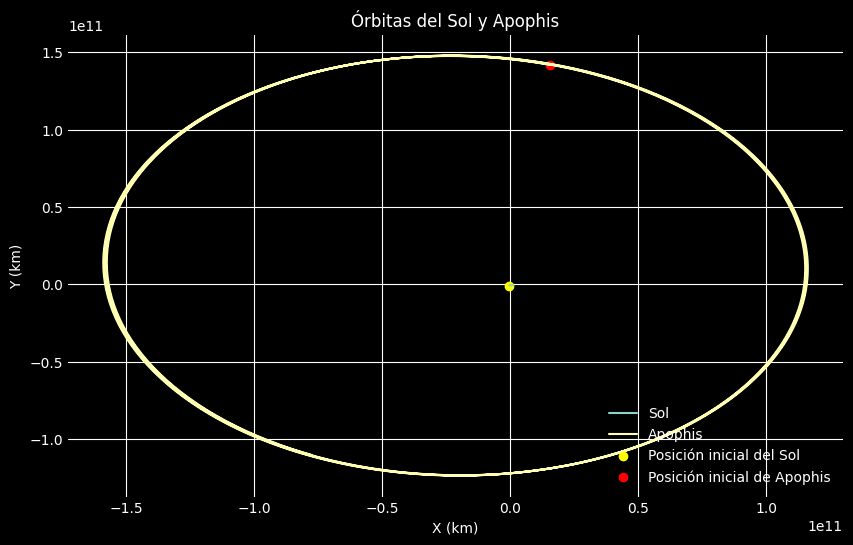

In [106]:
# Calculo de la fuerza gravitacional del Sol sobre Apophis

m_sol=pc.constantes.M_sun
m_apophis = calcular_masa_apophis_esferoide(450, 170, 3200)  # usando la masa calculada como esferoide con densidad 3200 kg/m^3
G = pc.constantes.G
#Distacia
# Para calcular como cambia la fuerza gravitacional en el tiempo, necesitamos conocer la distancia entre el Sol y Apophis en diferentes momentos.
# Podemos usar las efemérides de Apophis para obtener su posición en diferentes momentos
# usaremos rebound para simular la órbita de Apophis y obtener su posición en diferentes momentos
# tambien se va usar n.cuerpos para simular la órbita de Apophis y obtener su posición en diferentes momentos

tabla, jd, X_sol = pc.consulta_horizons(
    id='Sun',
    location='@SSB',
    epochs='2026-03-24 00:00:00'
)

#para apophis
tabla_apophis, jd_apophis, X_apophis = pc.consulta_horizons(
    id='99942',
    location='@SSB',
    epochs='2026-03-26 00:00:00'
)


r_sol_0 = X_sol[:3]
v_sol_0 = X_sol[3:]

r_apophis_0 = X_apophis[:3]
v_apophis_0 = X_apophis[3:]
#metodo de euler para simular la órbita de Apophis y obtener su posición en diferentes momentos
delta = 1 *86400  # un día en segundos
r_sol_dt = r_sol_0 + v_sol_0 * delta
r_apophis_dt = r_apophis_0 + v_apophis_0 * delta
#calculo de la distancia entre el Sol y Apophis en diferentes momentos
mu_sol=pc.constantes.mu_sun
mu_apophis = G * m_apophis

rij_vector_s= r_apophis_0 - r_sol_0
v_apophis_dt = v_apophis_0 - mu_sol * rij_vector_s / np.linalg.norm(rij_vector_s)**3 * delta
#Calculo de las posiciones por 4 años usando el método de Euler
years=4
num_steps = years * 365  # número de pasos (días)
segundos_por_dia = 86400  # número de segundos en un día
T_total = num_steps * segundos_por_dia  # tiempo total de simulación en segundos

N_steps =int(T_total // delta)  # número de pasos de integración
# Inicializar arrays para almacenar las posiciones
r_apophis=r_apophis_0.copy()
v_apophis=v_apophis_0.copy()


r_sol=r_sol_0.copy()
v_sol=v_sol_0.copy()
r_apophis_hist = []
r_sol_hist = []
for step in range(N_steps):

    r_apophis_hist.append(r_apophis.copy())
    r_sol_hist.append(r_sol.copy()) 
    # Calcular la distancia entre el Sol y Apophis
    rij_vector = r_apophis - r_sol
    r = np.linalg.norm(rij_vector)
    
    # Calcular la aceleración de Apophis debido a la gravedad del Sol
    a_apophis = -mu_sol * rij_vector / r**3
    a_sol = mu_apophis * rij_vector / r**3  # reacción de la fuerza sobre el Sol
    
    # Actualizar la velocidad y posición de Apophis usando el método de Euler
    v_apophis += a_apophis * delta
    r_apophis += v_apophis * delta

    # Actualizar la velocidad y posición del Sol usando el método de Euler
    v_sol += a_sol * delta
    r_sol += v_sol * delta
    
    # Almacenar las posiciones para graficar
    r_apophis_hist.append(r_apophis.copy())
    r_sol_hist.append(r_sol.copy())

r_apophis_hist=np.array(r_apophis_hist)
r_sol_hist=np.array(r_sol_hist)
plt.figure(figsize=(10, 6))
plt.plot(r_sol_hist[:, 0], r_sol_hist[:, 1], label='Sol')
plt.plot(r_apophis_hist[:, 0], r_apophis_hist[:, 1], label='Apophis')
plt.scatter(r_sol_0[0], r_sol_0[1], color='yellow', label='Posición inicial del Sol')
plt.scatter(r_apophis_0[0], r_apophis_0[1], color='red', label='Posición inicial de Apophis')
plt.legend()    
plt.xlabel('X (km)')
plt.ylabel('Y (km)')
plt.title('Órbitas del Sol y Apophis')

In [107]:
import pandas as pd
data_puntos = []
for step in range(N_steps):
    # Calcular vector distancia y magnitud
    rij_vector = r_apophis - r_sol
    distancia = np.linalg.norm(rij_vector)
    
    fuerza_magnitud = (G * m_sol * m_apophis) / (distancia**2)
    

    data_puntos.append({
        'paso': step,
        'tiempo_seg': step * delta,
        'distancia_km': distancia,
        'fuerza_n': fuerza_magnitud,
        'sol_x': r_sol[0],
        'sol_y': r_sol[1],
        'apophis_x': r_apophis[0],
        'apophis_y': r_apophis[1]
    })
    
 
   
    a_apophis = -mu_sol * rij_vector / distancia**3
    a_sol = mu_apophis * rij_vector / distancia**3
    
 
    v_apophis += a_apophis * delta
    v_sol += a_sol * delta
    

    r_apophis += v_apophis * delta
    r_sol += v_sol * delta

df_resultados = pd.DataFrame(data_puntos)

# Mostrar las primeras filas
print(df_resultados.head())

   paso  tiempo_seg  distancia_km  fuerza_n    sol_x     sol_y  apophis_x  \
0     0           0      1.35e+11  1.58e+08 1.15e+09 -6.06e+08  -7.77e+10   
1     1       86400      1.35e+11  1.60e+08 1.15e+09 -6.06e+08  -7.52e+10   
2     2      172800      1.34e+11  1.61e+08 1.15e+09 -6.06e+08  -7.27e+10   
3     3      259200      1.34e+11  1.62e+08 1.15e+09 -6.06e+08  -7.01e+10   
4     4      345600      1.33e+11  1.63e+08 1.15e+09 -6.06e+08  -6.76e+10   

   apophis_y  
0  -1.10e+11  
1  -1.11e+11  
2  -1.13e+11  
3  -1.14e+11  
4  -1.15e+11  


Text(0.5, 0.92, 'Órbitas del Sol y Apophis en 3D')

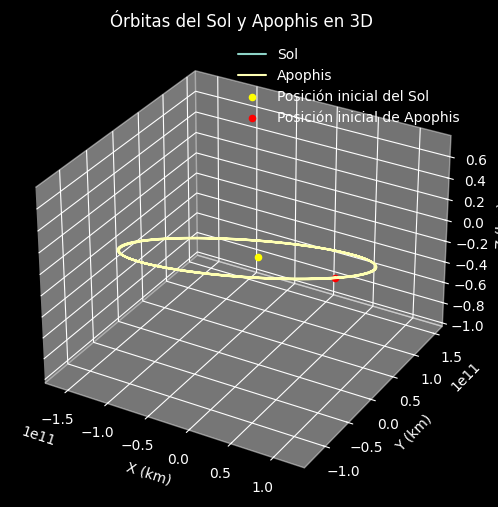

In [108]:
#Grafico 3D
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(r_sol_hist[:, 0], r_sol_hist[:, 1], r_sol_hist[:, 2], label='Sol')
ax.plot(r_apophis_hist[:, 0], r_apophis_hist[:, 1], r_apophis_hist[:, 2], label='Apophis')
ax.scatter(r_sol_0[0], r_sol_0[1], r_sol_0[2], color='yellow', label='Posición inicial del Sol')
ax.scatter(r_apophis_0[0], r_apophis_0[1], r_apophis_0[2], color='red', label='Posición inicial de Apophis')
ax.legend()
ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.set_zlabel('Z (km)')
ax.set_title('Órbitas del Sol y Apophis en 3D')


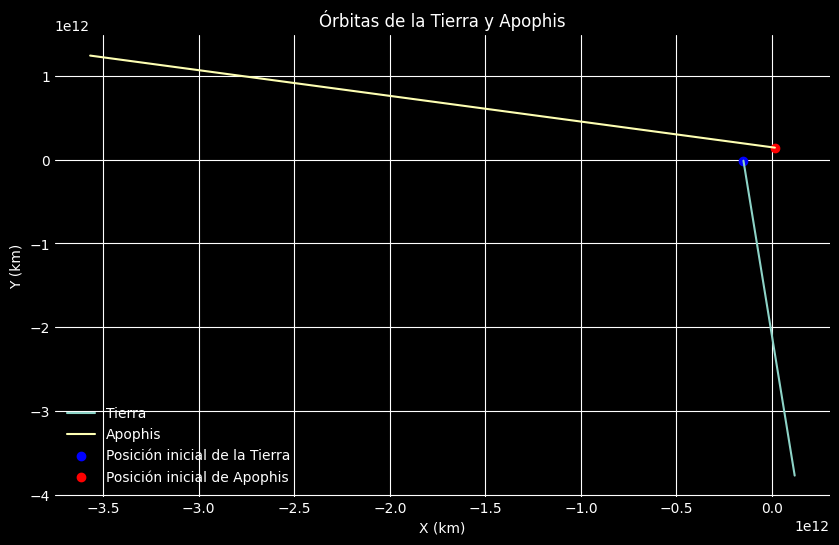

In [109]:
m_earth=pc.constantes.M_earth
tabla_tierra, jd_tierra, X_tierra = pc.consulta_horizons(
    id='399',
    location='@SSB',
    epochs='2026-03-26 00:00:00'
)

r_tierra_0 = X_tierra[:3]
v_tierra_0 = X_tierra[3:]

delta = 1 *86400  # un día en segundos
r_tierra_dt = r_tierra_0 + v_tierra_0 * delta
mu_earth = G * m_earth
rij_vector_earth = r_apophis_0 - r_tierra_0
v_apophis_dt_earth = v_apophis_0 - mu_earth * rij_vector_earth / np.linalg.norm(rij_vector_earth)**3 * delta

years=4
num_steps = years * 365  # número de pasos (días)
segundos_por_dia = 86400  # número de segundos en un día
T_total = num_steps * segundos_por_dia  # tiempo total de simulación en segundos
N_steps =int(T_total // delta)  # número de pasos de integración
# Inicializar arrays para almacenar las posiciones
r_apophis_e=r_apophis_0.copy()
v_apophis_e=v_apophis_0.copy()
r_tierra=r_tierra_0.copy()
v_tierra=v_tierra_0.copy()
r_apophis_hist_e = []
r_tierra_hist = []
for step in range(N_steps):

    r_apophis_hist_e.append(r_apophis_e.copy())
    r_tierra_hist.append(r_tierra.copy()) 
    # Calcular la distancia entre la Tierra y Apophis
    rij_vector = r_apophis_e - r_tierra
    r = np.linalg.norm(rij_vector)
    
    # Calcular la aceleración de Apophis debido a la gravedad de la Tierra
    a_apophis = -mu_earth * rij_vector / r**3
    a_tierra = mu_apophis * rij_vector / r**3  # reacción de la fuerza sobre la Tierra
    
    # Actualizar la velocidad y posición de Apophis usando el método de Euler
    v_apophis_e += a_apophis * delta
    r_apophis_e += v_apophis_e * delta

    # Actualizar la velocidad y posición de la Tierra usando el método de Euler
    v_tierra += a_tierra * delta
    r_tierra += v_tierra * delta
    
    # Almacenar las posiciones para graficar
    r_apophis_hist_e.append(r_apophis_e.copy())
    r_tierra_hist.append(r_tierra.copy())

r_apophis_hist_e=np.array(r_apophis_hist_e)
r_tierra_hist=np.array(r_tierra_hist)
plt.figure(figsize=(10, 6))
plt.plot(r_tierra_hist[:, 0], r_tierra_hist[:, 1], label='Tierra')
plt.plot(r_apophis_hist_e[:, 0], r_apophis_hist_e[:, 1], label='Apophis')
plt.scatter(r_tierra_0[0], r_tierra_0[1], color='blue', label='Posición inicial de la Tierra')
plt.scatter(r_apophis_0[0], r_apophis_0[1], color='red', label='Posición inicial de Apophis')
plt.legend()    
plt.xlabel('X (km)')
plt.ylabel('Y (km)')
plt.title('Órbitas de la Tierra y Apophis')
plt.show()


¿Qué ocurre con esta gráfica? Al utilizar velocidades heliocéntricas pero descartar la influencia del Sol ($​\mu_\odot$) en el cálculo de la aceleración, el modelo falla al representar la realidad física. A una distancia de 150 millones de kilómetros, la gravedad de la Tierra es demasiado débil para retener a objetos que se desplazan a 30 km/s; sin la atracción solar necesaria para curvar sus trayectorias, la inercia de los cuerpos predomina sobre la fuerza terrestre, resultando en las trayectorias rectilíneas de escape que se observan en la simulación.

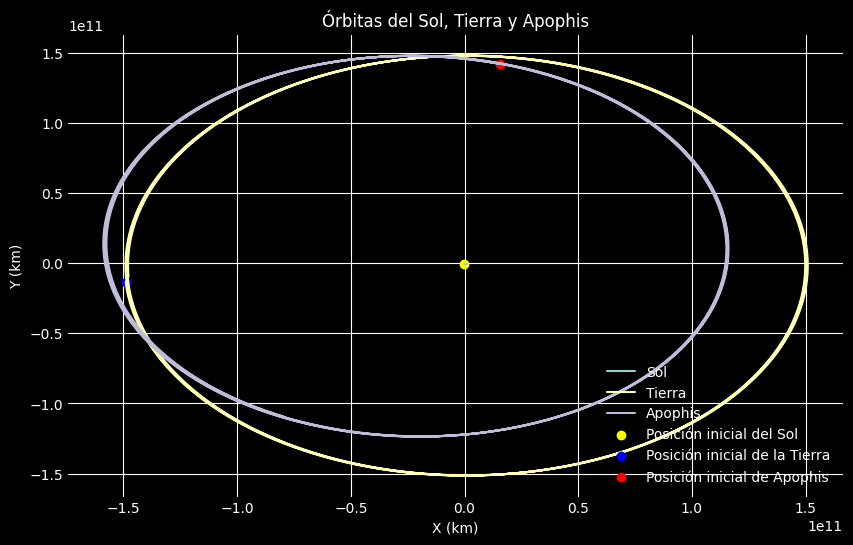

In [110]:
r_sol_f=r_sol_0.copy()
v_sol_f=v_sol_0.copy()

r_tierra_f=r_tierra_0.copy()
v_tierra_f=v_tierra_0.copy()

r_apophis_f=r_apophis_0.copy()
v_apophis_f=v_apophis_0.copy()

r_apophis_hist_f = []
r_tierra_hist_f = []
r_sol_hist_f = []
for step in range(N_steps):
    # 1. GUARDAR HISTORIAL (Solo una vez por paso)
    r_apophis_hist_f.append(r_apophis_f.copy())
    r_tierra_hist_f.append(r_tierra_f.copy())
    r_sol_hist_f.append(r_sol_f.copy())

    # 2. VECTORES DE DISTANCIA
    rij_sol_ap = r_apophis_f - r_sol_f
    rij_sol_tie = r_tierra_f - r_sol_f
    rij_tie_ap = r_apophis_f - r_tierra_f

    # MAGNITUDES (normas)
    d_sol_ap = np.linalg.norm(rij_sol_ap)
    d_sol_tie = np.linalg.norm(rij_sol_tie)
    d_tie_ap = np.linalg.norm(rij_tie_ap)

    # 3. ACELERACIONES (Vectores)
    # Aceleración de Apophis (atraído por Sol y Tierra)
    a_apophis = -mu_sol * rij_sol_ap / d_sol_ap**3 - mu_earth * rij_tie_ap / d_tie_ap**3
    
    # Aceleración de la Tierra (atraída por Sol y Apophis)
    a_tierra = -mu_sol * rij_sol_tie / d_sol_tie**3 + mu_apophis * rij_tie_ap / d_tie_ap**3
    
    # Aceleración del Sol (atraído por Tierra y Apophis - opcional pero recomendado)
    a_sol = mu_earth * rij_sol_tie / d_sol_tie**3 + mu_apophis * rij_sol_ap / d_sol_ap**3

    # 4. ACTUALIZAR VELOCIDADES (Método de Euler)
    v_apophis_f += a_apophis * delta
    v_tierra_f += a_tierra * delta
    v_sol_f    += a_sol * delta

    # 5. ACTUALIZAR POSICIONES
    r_apophis_f += v_apophis_f * delta
    r_tierra_f += v_tierra_f * delta
    r_sol_f    += v_sol_f * delta

# Convertir a arrays para graficar
r_apophis_hist_f = np.array(r_apophis_hist_f)
r_tierra_hist_f = np.array(r_tierra_hist_f)
r_sol_hist_f = np.array(r_sol_hist_f)

plt.figure(figsize=(10, 6))
plt.plot(r_sol_hist_f[:, 0], r_sol_hist_f[:, 1], label  ='Sol')
plt.plot(r_tierra_hist_f[:, 0], r_tierra_hist_f[:, 1], label='Tierra')
plt.plot(r_apophis_hist_f[:, 0], r_apophis_hist_f[:, 1], label='Apophis')
plt.scatter(r_sol_0[0], r_sol_0[1], color='yellow', label='Posición inicial del Sol')
plt.scatter(r_tierra_0[0], r_tierra_0[1], color='blue', label='Posición inicial de la Tierra')
plt.scatter(r_apophis_0[0], r_apophis_0[1], color='red', label='Posición inicial de Apophis')
plt.legend()
plt.xlabel('X (km)')
plt.ylabel('Y (km)')
plt.title('Órbitas del Sol, Tierra y Apophis')  
plt.show()

### Integracion con Rebound

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Earth'... 
Found: Earth-Moon Barycenter (3) (chosen from query 'Earth')
Searching NASA Horizons for '99942'... 
Found: 99942 Apophis (2004 MN4) 


/mnt/c/Users/ASUS/OneDrive/Documentos/.venv/lib/python3.12/site-packages/rebound/horizons.py:184: RuntimeWarning: Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.
  warnings.warn("Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.", RuntimeWarning)


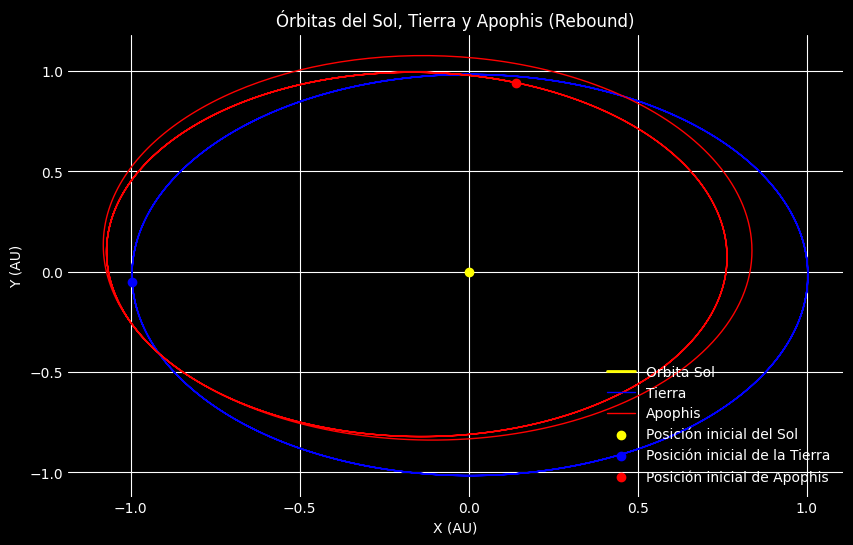

In [111]:
#Sol- Apophis
import rebound as rb

sim_solar = rb.Simulation()
sim_solar.units = ('days', 'AU', 'Msun')  # unidades canónicas    

sim_solar.add('Sun',date='2026-03-24 00:00')
sim_solar.add('Earth',date='2026-03-24 00:00')
sim_solar.add('99942',date='2026-03-24 00:00')


sim_solar.G
sim_solar.move_to_com()

n_puntos = 1000
tiempos = np.linspace(0, 4 * 365.25, n_puntos) # De 0 a 1461 días aproximadamente
#en canonicas (unidad de masa solar, unidad de distancia UA, unidad de tiempo año)
x_sol, y_sol = np.zeros(n_puntos), np.zeros(n_puntos)
x_tie, y_tie = np.zeros(n_puntos), np.zeros(n_puntos)
x_apo, y_apo = np.zeros(n_puntos), np.zeros(n_puntos)

for i, t in enumerate(tiempos):
    sim_solar.integrate(t)
    x_sol[i], y_sol[i] = sim_solar.particles[0].x, sim_solar.particles[0].y
    x_tie[i], y_tie[i] = sim_solar.particles[1].x, sim_solar.particles[1].y
    x_apo[i], y_apo[i] = sim_solar.particles[2].x, sim_solar.particles[2].y

plt.figure(figsize=(10, 6))
plt.plot(x_sol, y_sol, label='Orbita Sol', color='yellow', lw=2) 
plt.plot(x_tie, y_tie, label='Tierra', color='blue', lw=1)
plt.plot(x_apo, y_apo, label='Apophis', color='red', lw=1)
plt.scatter(x_sol[0], y_sol[0], color='yellow', label='Posición inicial del Sol')
plt.scatter(x_tie[0], y_tie[0], color='blue', label='Posición inicial de la Tierra')
plt.scatter(x_apo[0], y_apo[0], color='red', label='Posición inicial de Apophis')
plt.legend()
plt.xlabel('X (AU)')
plt.ylabel('Y (AU)')
plt.title('Órbitas del Sol, Tierra y Apophis (Rebound)')
plt.show()



Ahora si con la posiciones nos disponemos a calcular la fuerza

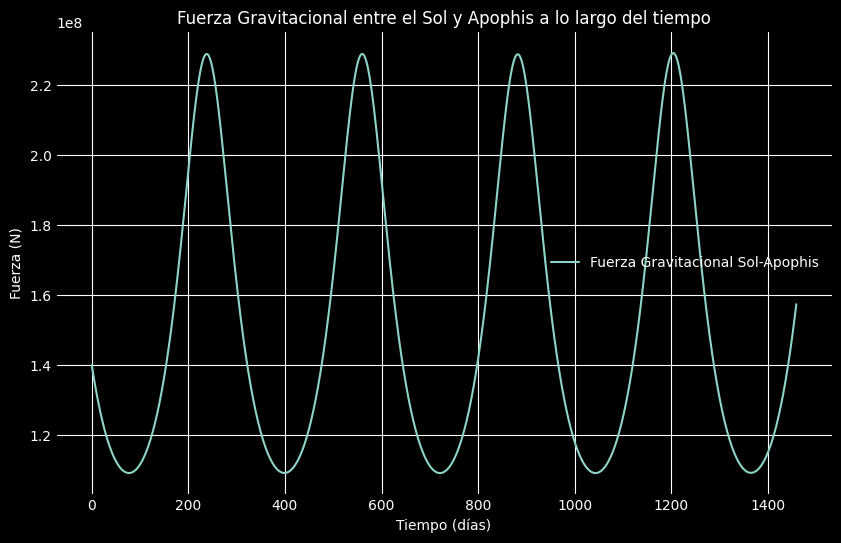

In [112]:
m_sol=pc.constantes.M_sun
m_apophis = calcular_masa_apophis_esferoide(450, 170, 3200)  # usando la masa calculada como esferoide con densidad 3200 kg/m^3
G = pc.constantes.G


def calcular_fuerza_gravitacional(m1, m2, r):
    G = pc.constantes.G
    return G * m1 * m2 / r**2

F_sol_apophis = np.zeros(N_steps)
for i in range(N_steps):
    r = np.linalg.norm(r_apophis_hist_f[i] - r_sol_hist_f[i])
    F_sol_apophis[i] = calcular_fuerza_gravitacional(m_sol, m_apophis, r)
    
tiempos = np.arange(N_steps) * delta / 86400  # Convertir a días
plt.figure(figsize=(10, 6))
plt.plot(tiempos, F_sol_apophis, label='Fuerza Gravitacional Sol-Apophis')
plt.xlabel('Tiempo (días)')
plt.ylabel('Fuerza (N)')
plt.title('Fuerza Gravitacional entre el Sol y Apophis a lo largo del tiempo')
plt.legend() 
plt.show()



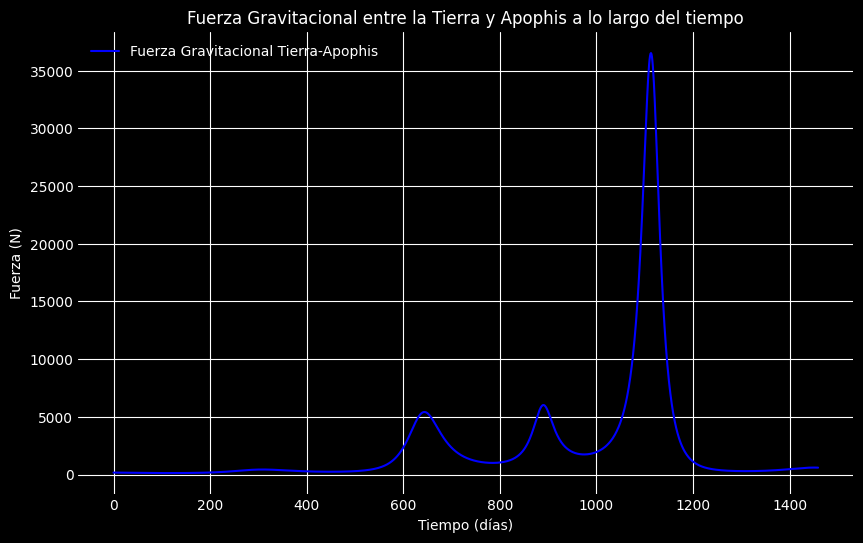

In [113]:
m_tierra=pc.constantes.M_earth
m_apophis = calcular_masa_apophis_esferoide(450, 170, 3200)  # usando la masa calculada como esferoide con densidad 3200 kg/m^3
G = pc.constantes.G
F_tierra_apophis = np.zeros(N_steps)
for i in range(N_steps):
    r = np.linalg.norm(r_apophis_hist_f[i] - r_tierra_hist_f[i])
    F_tierra_apophis[i] = calcular_fuerza_gravitacional(m_tierra, m_apophis, r)
    # Aquí podrías almacenar F_tierra_apophis en un array para graficar después 

plt.figure(figsize=(10, 6))
plt.plot(np.arange(N_steps) * delta / 86400, F_tierra_apophis, label='Fuerza Gravitacional Tierra-Apophis', color='blue')
plt.xlabel('Tiempo (días)') 
plt.ylabel('Fuerza (N)')
plt.title('Fuerza Gravitacional entre la Tierra y Apophis a lo largo del tiempo')
plt.legend()
plt.show()


Explicacion:

In [114]:
# Tabla de resultados
dist_sol_apophis = np.linalg.norm(r_apophis_hist_f - r_sol_hist_f, axis=1)
dist_tierra_apophis = np.linalg.norm(r_apophis_hist_f - r_tierra_hist_f, axis=1)
dias = np.arange(N_steps) * delta / 86400  # Convertir a días
fechas = pd.to_datetime('2026-03-24') + pd.to_timedelta(dias, unit='D')
idx_encuentro = np.argmin(dist_tierra_apophis) 
AU_KM = 149597870.7  # 1 AU en kilómetros

# 2. Definir un rango de días alrededor de ese encuentro (ej. 5 días antes y 5 después)
rango = range(idx_encuentro - 5, idx_encuentro + 10)

df_resultados = pd.DataFrame({
    'Fecha': [fechas[i] for i in rango],
    'Día Simulación': [dias[i] for i in rango],
    'Distancia al Sol (AU)': [dist_sol_apophis[i] / AU_KM for i in rango],
    'Distancia a la Tierra (km)': [dist_tierra_apophis[i] for i in rango],
    'Fuerza Sol (N)': [F_sol_apophis[i] for i in rango],
    'Fuerza Tierra (N)': [F_tierra_apophis[i] for i in rango]
})


pd.options.display.float_format = '{:,.2e}'.format # Usar notación científica
print("Resumen del Encuentro Cercano de Apophis (2029)")
print(df_resultados)

Resumen del Encuentro Cercano de Apophis (2029)
        Fecha  Día Simulación  Distancia al Sol (AU)  \
0  2029-04-05        1.11e+03               9.96e+02   
1  2029-04-06        1.11e+03               9.93e+02   
2  2029-04-07        1.11e+03               9.90e+02   
3  2029-04-08        1.11e+03               9.87e+02   
4  2029-04-09        1.11e+03               9.85e+02   
5  2029-04-10        1.11e+03               9.82e+02   
6  2029-04-11        1.11e+03               9.79e+02   
7  2029-04-12        1.12e+03               9.76e+02   
8  2029-04-13        1.12e+03               9.73e+02   
9  2029-04-14        1.12e+03               9.70e+02   
10 2029-04-15        1.12e+03               9.67e+02   
11 2029-04-16        1.12e+03               9.64e+02   
12 2029-04-17        1.12e+03               9.61e+02   
13 2029-04-18        1.12e+03               9.58e+02   
14 2029-04-19        1.12e+03               9.55e+02   

    Distancia a la Tierra (km)  Fuerza Sol (N)  Fuerza 

## Segundo experimento: Sistemas Jerárquicos y Perturbaciones (N-Cuerpos)
**Objetivo:** Analizar la estabilidad del sistema Sol-Tierra-Luna-Apophis y el efecto de Júpiter como perturbador principal.

*   **Fundamento Teórico:** Los sistemas de N-cuerpos se pueden estudiar mediante **Coordenadas de Jacobi**, donde el movimiento se descompone en pares jerárquicos. La aceleración perturbadora de un tercer cuerpo (Júpiter) se define como:
    $$\vec{a}_{pert} = G M_{jup} \left( \frac{\vec{r}_{j-a}}{|\vec{r}_{j-a}|^3} - \frac{\vec{r}_j}{|\vec{r}_j|^3} \right)$$
*   **Propuesta:** Comparar la trayectoria incluyendo y excluyendo a Júpiter para observar la desviación acumulada.

 A (Sol)
    ├── Aa (Tierra)
    │   └── Luna (Satélite de Aa)
    ├── Ab (Júpiter)
    └── Ac (Apophis)

In [115]:
#Masas
M_sol=pc.constantes.M_sun
M_earth=pc.constantes.M_earth
M_apophis = calcular_masa_apophis_esferoide(450, 170, 3200) 
M_luna = 7.35e22 # masa de la Luna en kg
M_jup=pc.constantes.M_jup

#Coordenadas
#Coordenadas del Sol, Tierra, Luna, Júpiter y Apophis en el sistema de referencia del Sol (heliocéntrico) en km
tabla_sol, jd_sol, X_sol = pc.consulta_horizons(
    id='Sun',
    location='@SSB',
    epochs='2026-03-26 00:00:00'
)
tabla_tierra, jd_tierra, X_tierra = pc.consulta_horizons(
    id='399',
    location='@SSB',
    epochs='2026-03-26 00:00:00'
)
tabla_luna, jd_luna, X_luna = pc.consulta_horizons(
    id='301',
    location='@SSB',
    epochs='2026-03-26 00:00:00'
)
tabla_jup, jd_jup, X_jup = pc.consulta_horizons(
    id='5',
    location='@SSB',
    epochs='2026-03-26 00:00:00'
)

tabla_apophis, jd_apophis, X_apophis = pc.consulta_horizons(
    id='99942',
    location='@SSB',
    epochs='2026-03-26 00:00:00'
)

#Sistemas

#Sistema Tierra-Luna
m_tl=M_earth + M_luna
#centro de masa tl
X_tl = (M_earth * X_tierra[0:3] + M_luna * X_luna[0:3]) / m_tl
V_tl = (M_earth * X_tierra[3:6] + M_luna * X_luna[3:6]) / m_tl


#Sistema Sol-Tierra
m_st = M_sol + M_earth
X_st = (M_sol * X_sol[0:3] + M_earth * X_tierra[0:3]) / m_st
V_st = (M_sol * X_sol[3:6] + M_earth * X_tierra[3:6]) / m_st

#Sistema Sol-Apophis
m_sa = M_sol + M_apophis
X_sa = (M_sol * X_sol[0:3] + M_apophis * X_apophis[0:3]) / m_sa
V_sa = (M_sol * X_sol[3:6] + M_apophis * X_apophis[3:6]) / m_sa

#Sistema Sol-Jupiter
m_sj = M_sol + M_jup
X_sj = (M_sol * X_sol[0:3] + M_jup * X_jup[0:3]) / m_sj
V_sj = (M_sol * X_sol[3:6] + M_jup * X_jup[3:6]) / m_sj

In [116]:
#Escogemos la posicion y velocidad inicial del centro de masa de todo el sistema Sol-Tierra-Apophis-Jupiter
M_total = M_sol + M_earth + M_luna + M_jup + M_apophis

# Cálculo del RCM (Posición) y VCM (Velocidad)
# Sumatoria de (masa_i * vector_i) / Masa_total
RCM = (M_sol*X_sol[0:3] + M_earth*X_tierra[0:3] + M_luna*X_luna[0:3] + 
       M_jup*X_jup[0:3] + M_apophis*X_apophis[0:3]) / M_total

VCM = (M_sol*X_sol[3:6] + M_earth*X_tierra[3:6] + M_luna*X_luna[3:6] + 
       M_jup*X_jup[3:6] + M_apophis*X_apophis[3:6]) / M_total

In [ ]:
#Subsistema Sol-Tierra-Luna
r_sol_tl = RCM  +  m_tl / M_total * X_st 
v_sol_tl = VCM  +  m_tl / M_total * V_st 
#posicion del centro de masa del sistema Tierra-Luna
r_tl = RCM  -  M_sol / M_total * X_st
v_tl = VCM  -  M_sol / M_total * V_st

#Subsistema Tierra-Luna
r_tierra_luna = RCM  +  m_tl / M_total * X_tl
v_tierra_luna = VCM  +  m_tl / M_total * V_tl
#posicion del centro de masa del sistema Tierra-Luna
r_luna = RCM  -  M_earth / M_total * X_tl
v_luna = VCM  -  M_earth / M_total * V_tl

#Subsistema Sol-Apophis
r_sol_ap = RCM  +  m_sa / M_total * X_sa   
v_sol_ap = VCM  +  m_sa / M_total * V_sa
#posicion del centro de masa del sistema Sol-Apophis
r_ap = RCM  -  M_sol / M_total * X_sa
v_ap = VCM  -  M_sol / M_total * V_sa

#Subsistema Sol-Jupiter
r_sol_jup = RCM  +  m_sj / M_total * X_sj
v_sol_jup = VCM  +  m_sj / M_total * V_sj
#posicion del centro de masa del sistema Sol-Jupiter
r_jup = RCM  -  M_sol / M_total * X_sj
v_jup = VCM  -  M_sol / M_total * V_sj

sistemas = [
    {     'm': M_sol,     'r': X_sol[0:3] - RCM,     'v': X_sol[3:6] - VCM},
    {  'm': M_earth,   'r': X_tierra[0:3] - RCM,   'v': X_tierra[3:6] - VCM},
    {   'm': M_luna,    'r': X_luna[0:3] - RCM,    'v': X_luna[3:6] - VCM},
    { 'm': M_jup,     'r': X_jup[0:3] - RCM,     'v': X_jup[3:6] - VCM},
    {'m': M_apophis, 'r': X_apophis[0:3] - RCM, 'v': X_apophis[3:6] - VCM}
]

# --- 5. Ejecutar Simulación ---
# Pymcel requiere que desempaquetes 5 valores según su código interno
ts = np.linspace(0, 4 * 365.25 * 86400, 5000) # Tiempo en SEGUNDOS para ncuerpos

# Llamada corregida
rs, vs, rps, vps, constantes = pc.ncuerpos_solucion(sistemas, ts)

ts = np.linspace(0, 4 * 365.25, N_steps)  # De 0 a 1461 días aproximadamente
#rs,vs,rps,vps = pc.ncuerpos_solucion(sistemas, ts)

###Correguir#

In [129]:

M_sol = pc.constantes.M_sun
M_earth = pc.constantes.M_earth
M_jup = pc.constantes.M_jup
M_luna = 7.35e22  # kg
M_apophis = calcular_masa_apophis_esferoide(450, 170, 3200)


fecha = '2026-03-26 00:00:00'

_, _, X_sol     = pc.consulta_horizons(id='Sun',    location='@SSB', epochs=fecha)
_, _, X_tierra  = pc.consulta_horizons(id='399',   location='@SSB', epochs=fecha)
_, _, X_luna    = pc.consulta_horizons(id='301',   location='@SSB', epochs=fecha)
_, _, X_jup     = pc.consulta_horizons(id='5',     location='@SSB', epochs=fecha)
_, _, X_apophis = pc.consulta_horizons(id='99942', location='@SSB', epochs=fecha)


M_total = M_sol + M_earth + M_luna + M_jup + M_apophis

RCM = (M_sol*X_sol[0:3] + M_earth*X_tierra[0:3] + M_luna*X_luna[0:3] +
       M_jup*X_jup[0:3] + M_apophis*X_apophis[0:3]) / M_total

VCM = (M_sol*X_sol[3:6] + M_earth*X_tierra[3:6] + M_luna*X_luna[3:6] +
       M_jup*X_jup[3:6] + M_apophis*X_apophis[3:6]) / M_total

#SISTEMA TIERRA-LUNA 
m_tl = M_earth + M_luna
X_tl = (M_earth * X_tierra[0:3] + M_luna * X_luna[0:3]) / m_tl
V_tl = (M_earth * X_tierra[3:6] + M_luna * X_luna[3:6]) / m_tl

# POSICIONES RELATIVAS AL CM TOTAL
r_sol = - (M_earth + M_luna + M_jup + M_apophis) / M_total * X_sol[0:3]
v_sol = - (M_earth + M_luna + M_jup + M_apophis) / M_total * X_sol[3:6]

# Tierra-Luna (tratada como un solo cuerpo por ahora)
r_tl = (M_sol / M_total) * (X_tl - X_sol[0:3])
v_tl = (M_sol / M_total) * (V_tl - X_sol[3:6])

# Apophis
r_ap = (M_sol / M_total) * (X_apophis[0:3] - X_sol[0:3])
v_ap = (M_sol / M_total) * (X_apophis[3:6] - X_sol[3:6])

# Júpiter
r_jup = (M_sol / M_total) * (X_jup[0:3] - X_sol[0:3])
v_jup = (M_sol / M_total) * (X_jup[3:6] - X_sol[3:6])


sistemas = [
    {'m': M_sol,      'r': r_sol,      'v': v_sol,     'nombre': 'Sol'},
    {'m': m_tl,       'r': r_tl,       'v': v_tl,      'nombre': 'Tierra-Luna'},
    {'m': M_apophis,  'r': r_ap,       'v': v_ap,      'nombre': 'Apophis'},
    {'m': M_jup,      'r': r_jup,      'v': v_jup,     'nombre': 'Jupiter'}
]


N_steps = 2000
ts = np.linspace(0, 4 * 365.25, N_steps)   # 4 años

rs, vs, rps, vps = pc.ncuerpos_solucion(sistemas, ts)

print("Simulación completada!")
print(f"Forma de rs: {rs.shape}")

/mnt/c/Users/ASUS/OneDrive/Documentos/.venv/lib/python3.12/site-packages/pymcel/__init__.py:1413: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  solucion=odeint(edm_ncuerpos_eficiente,Y0s,ts,args=(N,mus))
/mnt/c/Users/ASUS/OneDrive/Documentos/.venv/lib/python3.12/site-packages/pymcel/__init__.py:1426: RuntimeWarning: invalid value encountered in multiply
  RCM=RCM+mus[i]*rs[i,:,:]
/mnt/c/Users/ASUS/OneDrive/Documentos/.venv/lib/python3.12/site-packages/pymcel/__init__.py:1435: RuntimeWarning: invalid value encountered in subtract
  rps=rs-RCM
/mnt/c/Users/ASUS/OneDrive/Documentos/.venv/lib/python3.12/site-packages/pymcel/__init__.py:1436: RuntimeWarning: invalid value encountered in subtract
  vps=subtract(vs,PCM/M)
/mnt/c/Users/ASUS/OneDrive/Documentos/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2803: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real
/mnt/c/User

ValueError: too many values to unpack (expected 4)

In [120]:
from celluloid import Camera

Velocidad del CM (debería ser casi cero): 3288.6571953842094


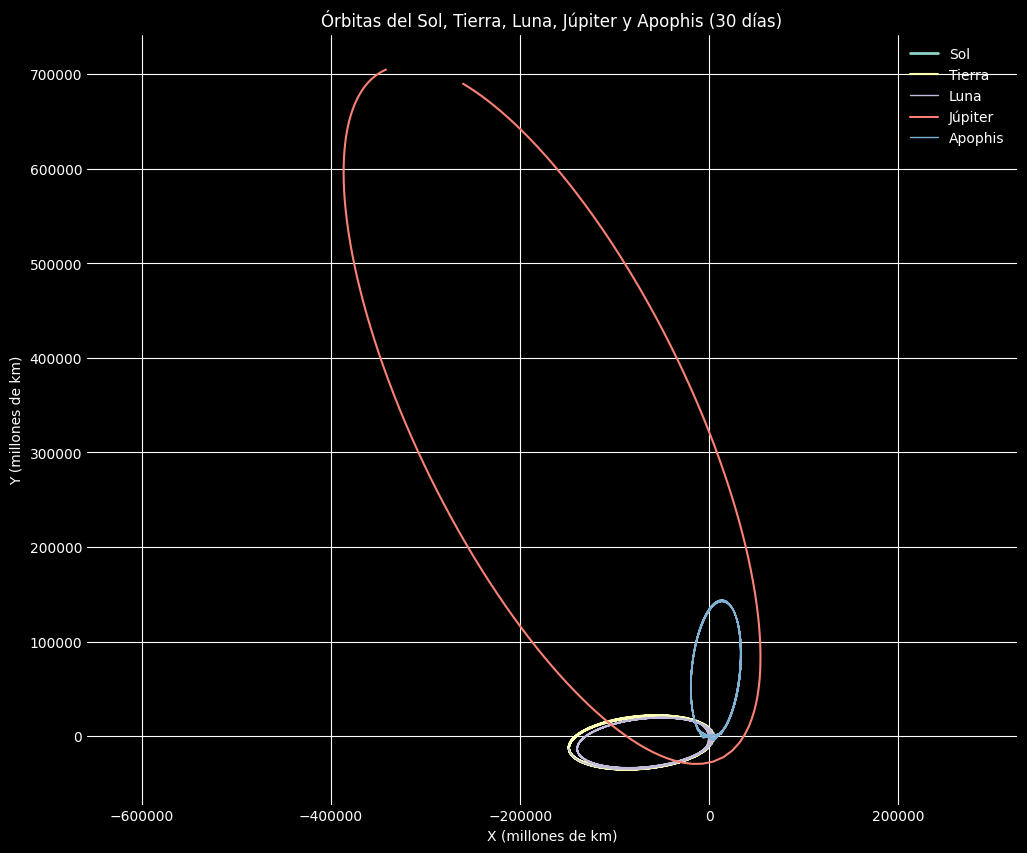

In [130]:

M_sol = pc.constantes.M_sun
M_earth = pc.constantes.M_earth
M_jup = pc.constantes.M_jup
M_luna = 7.35e22


M_apophis = calcular_masa_apophis_esferoide(450, 170, 3200)

fecha = '2026-03-26 00:00:00'

_, _, X_sol     = pc.consulta_horizons(id='Sun',    location='@SSB', epochs=fecha)
_, _, X_tierra  = pc.consulta_horizons(id='399',   location='@SSB', epochs=fecha)
_, _, X_luna    = pc.consulta_horizons(id='301',   location='@SSB', epochs=fecha)
_, _, X_jup     = pc.consulta_horizons(id='5',     location='@SSB', epochs=fecha)
_, _, X_apophis = pc.consulta_horizons(id='99942', location='@SSB', epochs=fecha)

# Convertir a metros
X_sol = X_sol * 1000
X_tierra = X_tierra * 1000
X_luna = X_luna * 1000
X_jup = X_jup * 1000
X_apophis = X_apophis * 1000

# Centro de Masa Total
M_total = M_sol + M_earth + M_luna + M_jup + M_apophis

RCM = (M_sol*X_sol[0:3] + M_earth*X_tierra[0:3] + M_luna*X_luna[0:3] +
       M_jup*X_jup[0:3] + M_apophis*X_apophis[0:3]) / M_total

VCM = (M_sol*X_sol[3:6] + M_earth*X_tierra[3:6] + M_luna*X_luna[3:6] +
       M_jup*X_jup[3:6] + M_apophis*X_apophis[3:6]) / M_total

print("Velocidad del CM (debería ser casi cero):", np.linalg.norm(VCM))

# Posiciones y velocidades relativas al CM
r_sol = X_sol[0:3] - RCM
v_sol = X_sol[3:6] - VCM

r_tierra = X_tierra[0:3] - RCM
v_tierra = X_tierra[3:6] - VCM

r_luna = X_luna[0:3] - RCM
v_luna = X_luna[3:6] - VCM

r_jup = X_jup[0:3] - RCM
v_jup = X_jup[3:6] - VCM

r_ap = X_apophis[0:3] - RCM
v_ap = X_apophis[3:6] - VCM

# Sistema
sistema = [
    {'m': M_sol,     'r': r_sol,     'v': v_sol,     'nombre': 'Sol'},
    {'m': M_earth,   'r': r_tierra,  'v': v_tierra,  'nombre': 'Tierra'},
    {'m': M_luna,    'r': r_luna,    'v': v_luna,    'nombre': 'Luna'},
    {'m': M_jup,     'r': r_jup,     'v': v_jup,     'nombre': 'Jupiter'},
    {'m': M_apophis, 'r': r_ap,      'v': v_ap,      'nombre': 'Apophis'}
]


ts = np.linspace(0, 360 * 86400, 1000)   

rs, vs, rps, vps, const = pc.ncuerpos_solucion(sistema, ts)


plt.figure(figsize=(12, 10))
plt.plot(rps[0,:,0]/1e9, rps[0,:,1]/1e9, label='Sol', lw=2)
plt.plot(rps[1,:,0]/1e9, rps[1,:,1]/1e9, label='Tierra', lw=1.5)
plt.plot(rps[2,:,0]/1e9, rps[2,:,1]/1e9, label='Luna', lw=1)
plt.plot(rps[3,:,0]/1e9, rps[3,:,1]/1e9, label='Júpiter', lw=1.5)
plt.plot(rps[4,:,0]/1e9, rps[4,:,1]/1e9, label='Apophis', lw=1)

plt.legend()
plt.axis('equal')
plt.grid(True)
plt.title('Órbitas del Sol, Tierra, Luna, Júpiter y Apophis (30 días)')
plt.xlabel('X (millones de km)')
plt.ylabel('Y (millones de km)')
plt.show()

creo que esta grafica no esta bien

## Tercer experimento: Dibujo de la trayectoria con elementos orbitales
**Objetivo:** Transformar los vectores de estado $(\vec{r}, \vec{v})$ obtenidos de las efemérides en los 6 elementos keplerianos para describir la cónica de la órbita.

*   **Fundamento Teórico:** A partir de la constante del momento angular específico $\vec{h} = \vec{r} \times \vec{v}$ y el vector de excentricidad $\vec{e} = \frac{\vec{v} \times \vec{h}}{\mu} - \hat{r}$, calculamos:
    - Semieje mayor ($a$), Excentricidad ($e$), Inclinación ($i$), Longitud del nodo ascendente ($\Omega$), Argumento del periapsis ($\omega$) y Anomalía verdadera ($\theta$).
*   **Visualización:** Dibujo de la elipse heliocéntrica antes del encuentro cercano.

### Elementos de Apophis

In [ ]:

def calculate_orbital_elements(rvec, vvec, mu):
    r = np.linalg.norm(rvec)
    v = np.linalg.norm(vvec)
    hvec = np.cross(rvec, vvec)
    h = np.linalg.norm(hvec)
    evec = (np.cross(vvec, hvec) / mu) - (rvec / r)
    e = np.linalg.norm(evec)
    p = h**2 / mu
    a = p / (1 - e**2)
    Q = a * (1 + e)
    
    I = np.arccos(np.clip(hvec[2] / h, -1.0, 1.0))
    k_hat = np.array([0, 0, 1])
    nvec = np.cross(k_hat, hvec)
    n = np.linalg.norm(nvec)

    if n != 0:
        Omega = np.arccos(np.clip(nvec[0] / n, -1.0, 1.0))
        if nvec[1] < 0: Omega = 2 * np.pi - Omega
    else: Omega = 0.0

    if n != 0 and e != 0:
        dot_product_ne = np.dot(nvec, evec)
        omega = np.arccos(np.clip(dot_product_ne / (n * e), -1.0, 1.0))
        if evec[2] < 0: omega = 2 * np.pi - omega
    else: omega = 0.0

    if e != 0:
        dot_product_er = np.dot(evec, rvec)
        f = np.arccos(np.clip(dot_product_er / (e * r), -1.0, 1.0))
        if np.dot(rvec, vvec) < 0: f = 2 * np.pi - f
    else:
        f = np.arctan2(rvec[1], rvec[0])
        if f < 0: f += 2 * np.pi

    return p, e, I, Omega, omega, f, a, Q

def conic_section(p, e, I, Omega, omega, f):
    r_perifocal = p / (1 + e * np.cos(f))
    x_perifocal = r_perifocal * np.cos(f)
    y_perifocal = r_perifocal * np.sin(f)

    cO, sO = np.cos(Omega), np.sin(Omega)
    cI, sI = np.cos(I), np.sin(I)
    cw, sw = np.cos(omega), np.sin(omega)

    R11 = cO * cw - sO * sw * cI
    R12 = -cO * sw - sO * cw * cI
    R21 = sO * cw + cO * sw * cI
    R22 = -sO * sw + cO * cw * cI
    R31 = sw * sI
    R32 = cw * sI

    x_inertial = R11 * x_perifocal + R12 * y_perifocal
    y_inertial = R21 * x_perifocal + R22 * y_perifocal
    z_inertial = R31 * x_perifocal + R32 * y_perifocal

    return (x_inertial, y_inertial, z_inertial)

### Elementos orbitales Apophis

Posición (km): [-1.22506168e+10 -1.23460232e+11  6.28778039e+09]
Velocidad (km/s): [34425.50065428  2288.75271218   691.47257222]
Semi-latus rectum (p): 134779924037.91 km
Eccentricity (e): 0.1986
Inclination (I): 3.34 degrees
Right Ascension of Ascending Node (Omega): 203.92 degrees
Argument of Perigee (omega): 125.14 degrees
True Anomaly (f): 295.32 degrees
Semi-major axis (a): 140316928393.27 km = 1.0023 AU
Aphelion distance (Q): 168190490125.55 km = 1.2014 AU


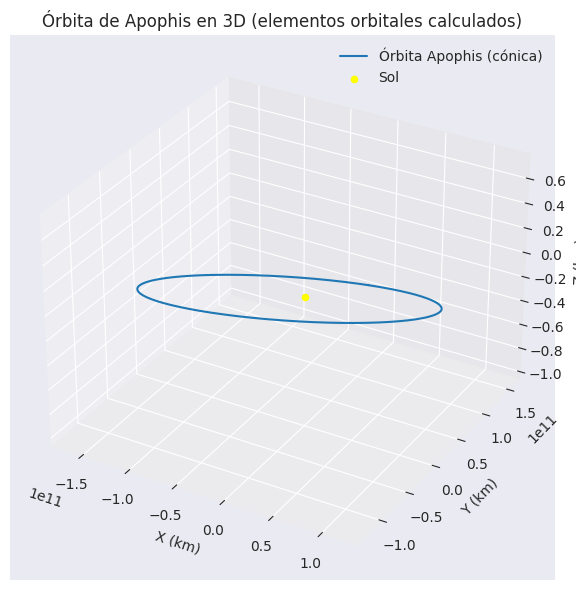

In [ ]:
tabla, jd, X = pc.consulta_horizons(id='Apophis', location ='@SSB', epochs='2025-11-21')
rvec= X[:3]
vvec = X[3:]
mu=pc.constantes.mu_sun + pc.constantes.mu_earth
#magnitudes
r=np.linalg.norm(rvec)
v=np.linalg.norm(vvec)
p, e, I, Omega, omega, f, a, Q = calculate_orbital_elements(rvec, vvec, mu)
rad=180/np.pi
print(f"Posición (km): {rvec}")
print(f"Velocidad (km/s): {vvec}")
print(f"Semi-latus rectum (p): {p:.2f} km")
print(f"Eccentricity (e): {e:.4f}")
print(f"Inclination (I): {I*rad:.2f} degrees")
print(f"Right Ascension of Ascending Node (Omega): {Omega*rad:.2f} degrees")
print(f"Argument of Perigee (omega): {omega*rad:.2f} degrees")
print(f"True Anomaly (f): {f*rad:.2f} degrees")
print(f"Semi-major axis (a): {a:.2f} km = {a/1.4e11:.4f} AU")
print(f"Aphelion distance (Q): {Q:.2f} km = {Q/1.4e11:.4f} AU")

# Graficar la cónica de la órbita de Apophis
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

num_points = 500
f_arr = np.linspace(0, 2*np.pi, num_points)
x3d = []
y3d = []
z3d = []
for f_i in f_arr:
    x, y, z = conic_section(p, e, I, Omega, omega, f_i)
    x3d.append(x)
    y3d.append(y)
    z3d.append(z)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x3d, y3d, z3d, label='Órbita Apophis (cónica)')
ax.scatter([0], [0], [0], color='yellow', label='Sol')
ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.set_zlabel('Z (km)')
ax.legend()
plt.title('Órbita de Apophis en 3D (elementos orbitales calculados)')
plt.tight_layout()
plt.show()

### Elementos orbitales tierra

In [ ]:
tabla_t, jd_t, X_t = pc.consulta_horizons(id='399', location ='@SSB', epochs='2025-11-21')
r_tierra = X_t[0:3]
rvec_t= X_t[:3]
vvec_t = X_t[3:]
mu=pc.constantes.mu_sun + pc.constantes.mu_earth
#magnitudes
r=np.linalg.norm(rvec_t)
v=np.linalg.norm(vvec_t)
p_t, e_t, I_t, Omega_t, omega_t, f_t, a_t, Q_t = calculate_orbital_elements(rvec_t, vvec_t, pc.constantes.mu_sun + pc.constantes.mu_earth)
rad=180/np.pi
print(f"Semi-latus rectum (p): {p_t:.2f} km")
print(f"Eccentricity (e): {e_t:.4f}")
print(f"Inclination (I): {I_t*rad:.2f} degrees")
print(f"Right Ascension of Ascending Node (Omega): {Omega_t*rad:.2f} degrees")
print(f"Argument of Perigee (omega): {omega_t*rad:.2f} degrees")
print(f"True Anomaly (f): {f_t*rad:.2f} degrees")
print(f"Semi-major axis (a): {a_t:.2f} km = {a_t/1.4e11 :.4f} AU")
print(f"Aphelion distance (Q): {Q_t:.2f} km = {Q_t/1.4e11:.4f} AU")

Semi-latus rectum (p): 147617753082.40 km
Eccentricity (e): 0.0126
Inclination (I): 0.01 degrees
Right Ascension of Ascending Node (Omega): 311.03 degrees
Argument of Perigee (omega): 172.59 degrees
True Anomaly (f): 294.94 degrees
Semi-major axis (a): 147641356458.32 km = 1.0546 AU
Aphelion distance (Q): 149508127584.46 km = 1.0679 AU


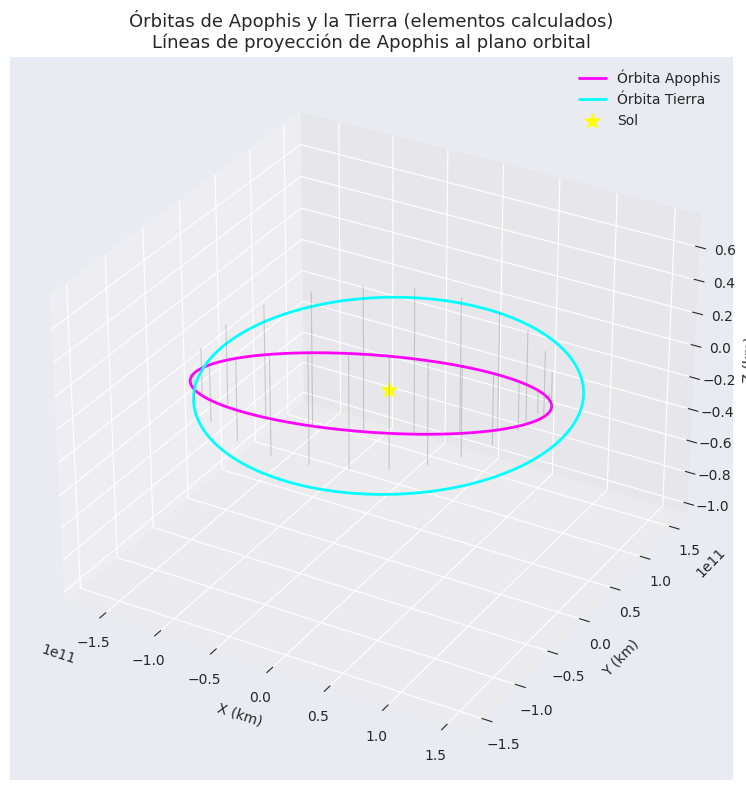

In [ ]:
# Graficar órbitas de Apophis y la Tierra usando elementos calculados desde vectores
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

num_points = 500
f_arr = np.linspace(0, 2*np.pi, num_points)

# Órbita Apophis
x3d_a, y3d_a, z3d_a = [], [], []
for f_i in f_arr:
    x, y, z = conic_section(p, e, I, Omega, omega, f_i)
    x3d_a.append(x)
    y3d_a.append(y)
    z3d_a.append(z)

# Órbita Tierra
x3d_t, y3d_t, z3d_t = [], [], []
for f_i in f_arr:
    x_t, y_t, z_t = conic_section(p_t, e_t, I_t, Omega_t, omega_t, f_i)
    x3d_t.append(x_t)
    y3d_t.append(y_t)
    z3d_t.append(z_t)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# Órbitas
ax.plot(x3d_a, y3d_a, z3d_a, label='Órbita Apophis', color='magenta', lw=2)
ax.plot(x3d_t, y3d_t, z3d_t, label='Órbita Tierra', color='cyan', lw=2)

# Líneas desde la órbita de Apophis al plano XY (plano orbital de la Tierra)
for i in range(0, num_points, 20):
    ax.plot([x3d_a[i], x3d_a[i]], [y3d_a[i], y3d_a[i]], [0, z3d_a[i]], color='gray', alpha=0.35, lw=0.8)

# Sol
ax.scatter([0], [0], [0], color='yellow', label='Sol', s=120, marker='*', zorder=10)

ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.set_zlabel('Z (km)')
ax.legend()
plt.title('Órbitas de Apophis y la Tierra (elementos calculados)\nLíneas de proyección de Apophis al plano orbital', fontsize=13)
plt.tight_layout()
plt.show()

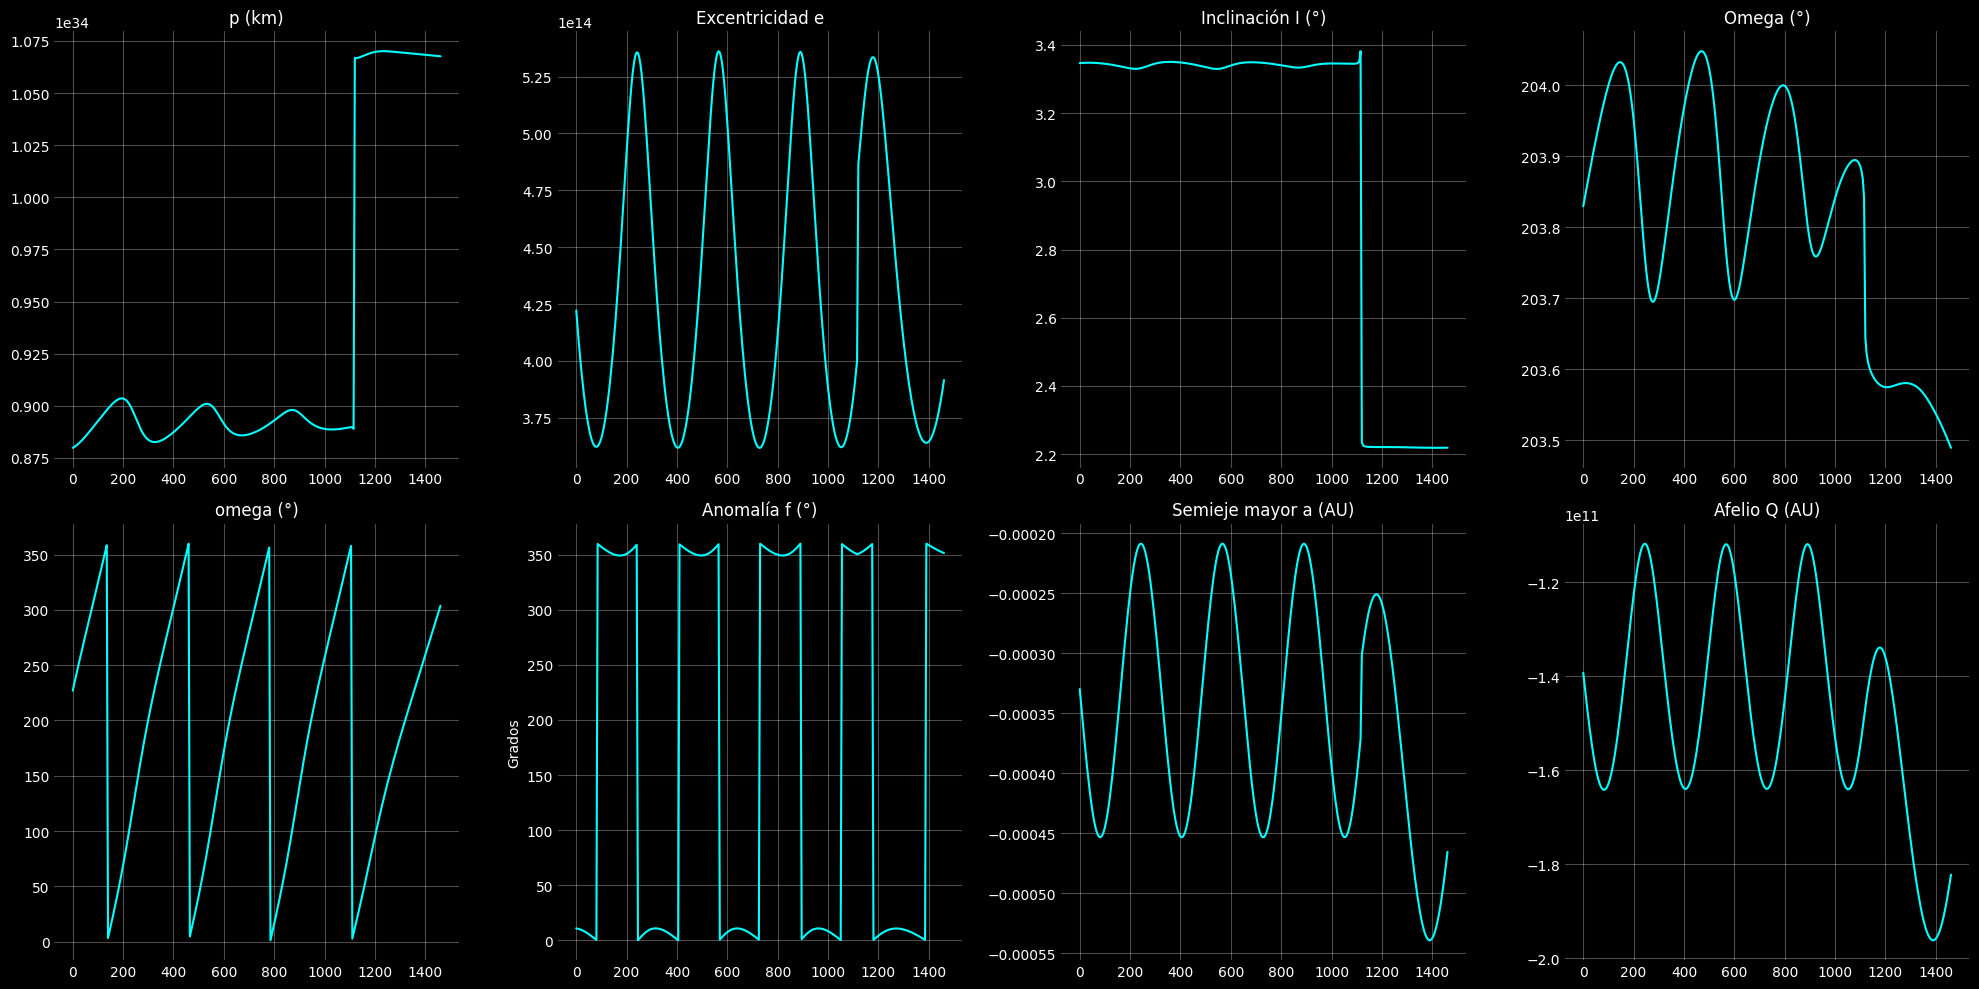

In [ ]:

AU_KM = 149597870.7
mu_sun = pc.constantes.mu_sun # km^3/s^2


start_date = '2026-03-24'
end_date = '2030-03-24'

tabla, jds, estados_df = pc.consulta_horizons(
    id='99942', 
    location='@SSB', 
    epochs={'start': start_date, 'stop': end_date, 'step': '5d'}
)

# Convertir DataFrame a Array de Numpy
estados = np.array(estados_df)

# Listas para guardar elementos calculados
p_list, e_list, I_list, Omega_list, omega_list, f_list, a_list, Q_list = [], [], [], [], [], [], [], []

AU_KM = 149597870.7
mu_sun = pc.constantes.mu_sun 


for i in range(len(jds)):
    
    r_km = estados[i, 0:3] * AU_KM
    
    v_km_s = estados[i, 3:6] * (AU_KM / 86400.0)
    
    p, e, I, Omega, omega, f, a, Q = calculate_orbital_elements(r_km, v_km_s, mu_sun)
    
    
    p_list.append(p)
    e_list.append(e)
    I_list.append(np.degrees(I))
    Omega_list.append(np.degrees(Omega))
    omega_list.append(np.degrees(omega))
    f_list.append(np.degrees(f))
    a_list.append(a / AU_KM) # Guardamos 'a' en AU para que sea legible
    Q_list.append(Q / AU_KM) # Guardamos 'Q' en AU para que sea legible

# --- GRAFICACIÓN ---
tiempos = jds - jds[0] # Días desde el inicio
fig, axs = plt.subplots(2, 4, figsize=(20, 10))
plt.style.use('dark_background')

# Lista de datos y títulos para automatizar las gráficas
data_plot = [
    (p_list, "p (km)"), (e_list, "Excentricidad e"), (I_list, "Inclinación I (°)"), (Omega_list, "Omega (°)"),
    (omega_list, "omega (°)"), (f_list, "Anomalía f (°)"), (a_list, "Semieje mayor a (AU)"), (Q_list, "Afelio Q (AU)")
]

for i, (data, titulo) in enumerate(data_plot):
    ax = axs[i//4, i%4]
    ax.plot(tiempos, data, color='cyan')
    ax.set_title(titulo)
    ax.grid(alpha=0.3)
    if "Anomalía" in titulo:
        ax.set_ylabel("Grados")

plt.tight_layout()
plt.show()

Observaciones:

## Cuarto Experimento: Animacion con la velocidad arial y la ecuacion de kepler

**Objetivo:** Validar la segunda ley de Kepler ($dA/dt = \text{const}$) y resolver la ecuación de posición en el tiempo.

*   **Fundamento Teórico:** 
    1.  **Velocidad Areal:** $\frac{dA}{dt} = \frac{1}{2} |\vec{h}| = \text{constante}$.
    2.  **Ecuación de Kepler:** Para encontrar la posición en el tiempo $t$, resolvemos para la Anomalía Excéntrica ($E$):
        $$M = E - e \sin E$$
        donde $M = n(t - T)$ es la anomalía media.
*   **Animación:** Se creará una visualización comparando el paso de tiempo constante vs. el barrido de áreas iguales.


In [134]:
def step_newton_kepler(E, e, M):
    return E - (E - e * np.sin(E) - M) / (1 - e * np.cos(E))


def solve_kepler(M, e, tol=1e-8, max_iter=100):
    E = M  # Estimación inicial razonable para excentricidades bajas/medias
    for _ in range(max_iter):
        E_new = step_newton_kepler(E, e, M)
        if abs(E_new - E) < tol:
            return E_new
        E = E_new
    return E



## Quinto experimento: El Teorema de la Energía (Vis-Viva)
**Objetivo:** Estudiar el intercambio de energía cinética y potencial durante el sobrevuelo terrestre.

*   **Fundamento Teórico:** La ecuación de **Vis-Viva** relaciona la velocidad con la distancia:
    $$v^2 = \mu \left( \frac{2}{r} - \frac{1}{a} \right)$$
*   **Análisis:** Se graficará la variación del semieje mayor ($a$) "instantáneo". Al pasar cerca de la Tierra, la energía orbital de Apophis respecto al Sol cambia, transformando su órbita de tipo *Aten* a tipo *Apolo* (o viceversa).


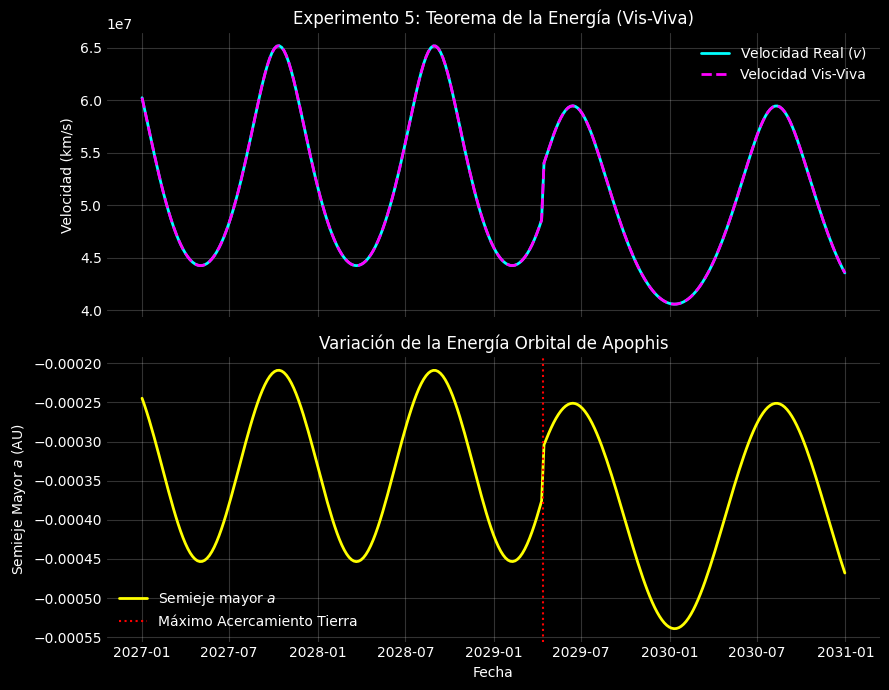

In [ ]:
AU_KM = 149597870.7
mu_sun = pc.constantes.mu_sun 

def calculate_a(r_vec_km, v_vec_km, mu):

    r = np.linalg.norm(r_vec_km)
    v = np.linalg.norm(v_vec_km)
    # epsilon = v^2/2 - mu/r = -mu/(2a)
    epsilon = (v**2 / 2) - (mu / r)
    return -mu / (2 * epsilon)



start_date = '2027-01-01'
end_date = '2031-01-01'

tabla, jds, estados_df = pc.consulta_horizons(
    id='99942', 
    location='@SSB', 
    epochs={'start': start_date, 'stop': end_date, 'step': '5d'}
)

estados = np.array(estados_df) 

# Convertir de AU y AU/día a KM y KM/S
pos_km = estados[:, 0:3] * AU_KM
vel_kms = estados[:, 3:6] * (AU_KM / 86400.0)

# VIS-VIVA 
num_puntos = len(jds)
semiejis_a = np.zeros(num_puntos)
vel_vis_viva = np.zeros(num_puntos)
vel_real = np.zeros(num_puntos)

for i in range(num_puntos):
    r_i = np.linalg.norm(pos_km[i])
    v_i = np.linalg.norm(vel_kms[i])
    
    # a instantáneo respecto al Sol
    a_inst = calculate_a(pos_km[i], vel_kms[i], mu_sun)
    semiejis_a[i] = a_inst
    
    # Velocidad teórica Vis-Viva
    vel_vis_viva[i] = np.sqrt(mu_sun * (2/r_i - 1/a_inst))
    vel_real[i] = v_i

# Convertir Julian Dates a objetos de fecha para el eje X
fechas = pd.to_datetime(jds - 2440587.5, unit='D')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

# Gráfico Superior: Velocidades
ax1.plot(fechas, vel_real, label='Velocidad Real ($v$)', color='cyan', lw=2)
ax1.plot(fechas, vel_vis_viva, label='Velocidad Vis-Viva', color='magenta', linestyle='--', lw=2)
ax1.set_ylabel('Velocidad (km/s)')
ax1.set_title('Experimento 5: Teorema de la Energía (Vis-Viva)')
ax1.legend()
ax1.grid(alpha=0.2)

# Gráfico Inferior: Semieje Mayor (Energía)
ax2.plot(fechas, semiejis_a / AU_KM, color='yellow', lw=2, label='Semieje mayor $a$')
# Resaltar el encuentro de 2029
ax2.axvline(pd.to_datetime('2029-04-13'), color='red', linestyle=':', label='Máximo Acercamiento Tierra')

ax2.set_ylabel('Semieje Mayor $a$ (AU)')
ax2.set_xlabel('Fecha')
ax2.set_title('Variación de la Energía Orbital de Apophis')
ax2.legend()
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

Interpretacion de gráficas:

## Sexto experimento: El Problema Restringido de los 3 Cuerpos (CR3BP)
**Objetivo:** Analizar la trayectoria de Apophis en el sistema rotante Tierra-Luna y su interacción con los Puntos de Lagrange.

*   **Fundamento Teórico:** En el sistema rotante, el potencial efectivo (o modificado) es:
    $$\Omega(x, y) = \frac{1}{2}(x^2 + y^2) + \frac{1-\mu}{r_1} + \frac{\mu}{r_2}$$
*   **Análisis:** Superponer la trayectoria de Apophis sobre las **Curvas de Velocidad Cero**. Se observará si el asteroide cruza los "cuellos" cerca de $L_1$ o $L_2$ durante su máxima aproximación.

## Septimo experimento: Efectos de Marea y Límite de Roche
**Objetivo:** Evaluar el riesgo de fragmentación del asteroide mediante un análisis de "What-if" variando su densidad.

*   **Fundamento Teórico:** El **Límite de Roche** ($d_R$) define la distancia mínima a la cual un cuerpo mantenido solo por su gravedad se desintegraría:
    $$d_R = R_M \left( 2 \frac{\rho_M}{\rho_m} \right)^{1/3}$$
    donde $\rho_M$ es la densidad de la Tierra y $\rho_m$ la de Apophis.
*   **Simulación:** Calcular a qué densidad crítica Apophis sufriría desprendimiento de masa (disrupción de marea) dado su perigeo de 31,000 km.